<a href="https://colab.research.google.com/github/joysujeeth1761/Adversarial_ML/blob/main/decision_based_attacks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Boundary Attack**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [3]:
#loading MNIST dataset
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=True
)

print("MNIST Loaded")

MNIST Loaded


In [4]:
# build CNN model
class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)

        self.pool = nn.MaxPool2d(2,2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(64 * 5 * 5, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))

        x = x.view(-1, 64 * 5 * 5)

        x = self.relu(self.fc1(x))

        x = self.fc2(x)

        return x

In [5]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SimpleCNN().to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model Initialized")

Model Initialized


In [6]:
#train CNN
epochs = 3

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss:.4f}")

print("Training Completed")

Epoch 1, Loss: 164.4290
Epoch 2, Loss: 48.5435
Epoch 3, Loss: 32.4311
Training Completed


In [8]:
#visualization fucntion
def show_image(img, title):

    img = img.squeeze().cpu().detach().numpy()

    plt.imshow(img, cmap='gray')

    plt.title(title)

    plt.axis('off')

    plt.show()

In [9]:
# creating an intial adversial example AS the boundary attack need the adversial image
def get_initial_adversarial(model,
                            image,
                            label):

    while True:

        random_image = torch.rand_like(
            image
        ).to(device)

        prediction = model(
            random_image
        ).argmax(dim=1)

        # Return if misclassified
        if prediction.item() != label.item():

            return random_image.detach()

In [10]:
#boundary attack function
def boundary_attack(model,
                    image,
                    label,
                    steps=100,
                    epsilon=0.01):

    model.eval()

    original_image = image.clone().detach()

    # Initial adversarial example
    adv_image = get_initial_adversarial(
        model,
        image,
        label
    )

    for step in range(steps):

        # Direction toward original image
        direction = (
            original_image - adv_image
        )

        direction = (
            direction
            / torch.norm(
                direction.view(-1),
                p=2
            )
        )

        # Random orthogonal perturbation
        noise = torch.randn_like(
            adv_image
        )

        noise = (
            noise
            / torch.norm(
                noise.view(-1),
                p=2
            )
        )

        # Candidate image
        candidate = (
            adv_image
            + epsilon * direction
            + 0.001 * noise
        )

        candidate = torch.clamp(
            candidate,
            0,
            1
        )

        prediction = model(
            candidate
        ).argmax(dim=1)

        # Keep if still adversarial
        if prediction.item() != label.item():

            adv_image = candidate.detach()

    return adv_image.detach()

In [11]:
# genreate boundary attack eaxmple
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

adv_image = boundary_attack(
    model,
    images,
    labels
)

print("Boundary Attack Completed")

Boundary Attack Completed


In [12]:
# compare predcitions
output1 = model(images)
pred1 = output1.argmax(dim=1)

output2 = model(adv_image)
pred2 = output2.argmax(dim=1)

print("Original Prediction:", pred1.item())

print("Adversarial Prediction:", pred2.item())

Original Prediction: 2
Adversarial Prediction: 8


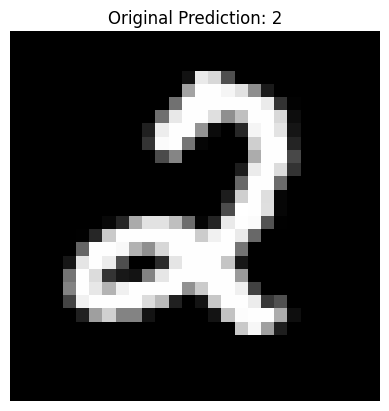

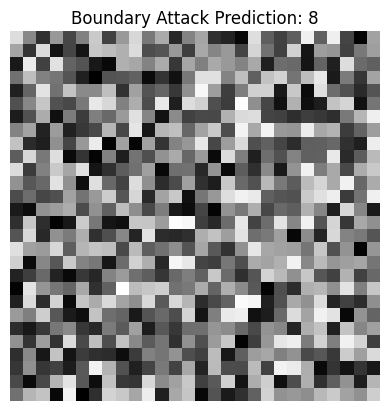

In [13]:
# visualization fuction for comparision
show_image(
    images[0],
    f"Original Prediction: {pred1.item()}"
)

show_image(
    adv_image[0],
    f"Boundary Attack Prediction: {pred2.item()}"
)

In [15]:
#testing accuracy of boundary attack
def test_boundary_attack(model,
                         loader,
                         steps=10):

    model.eval()

    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        adv_images = boundary_attack(
            model,
            images,
            labels,
            steps=steps
        )

        outputs = model(adv_images)

        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    accuracy = 100 * correct / total

    print(
        f"Boundary Attack Accuracy: {accuracy:.2f}%"
    )

In [16]:
test_boundary_attack(
    model,
    test_loader
)
# around ~10% accuracy

KeyboardInterrupt: 